 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Steven James                <br>
Student Number : L00196960        <br>
Due Date       : 12/05/26                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## Project Overview 

A fun hobby of mine is making learning tools for use with my daughter, this project provides a way for a parent to improve reading, phonics, engagement, and bonding in a positive way. I guess it falls as maybe an assistive technology

The idea is that a parent takes a few photos of pages from any kids book they are reading together. The system turns those pages into a fun learning activity by identifying words and main picture regions on the page, then creating simple engaging questions such as “Where is this object?”, “What sound does the object begin with?”, or other easy questions about the text.

The photos are shown with helpful highlights (boxes around text and picture areas) and each question is linked back to the right page so the parent can easily find it while reading with the child.

The core system uses OpenCV to detect text as well as outline the main picture regions. Full automatic object recognition (naming specific animals or objects like mouse, car, or apple) will not be supported its beyond in openCv in my view, however if time allows, I may experiment with yolo as i have access to both a powerful laptop and a midweight GPU (RTX3060) which are more than capable for this experimenttaion.

Testing 

For testing i plane to take photos of some of my kids books. Some i will take in poor light, some are folded etc, and some hand written text and image.

## Approach

We will adopt an incremental approach. Working this way we break the project down and each step has a clear outcome so we are focused. This makes the whole notebook easier to read, test and improve later on.

Each code step will carefully encapsulate its internal details. keeping the cells loosely coupled by passing only a high-level data object called the context between them. This context acts as a clean interface that carries everything needed from one step to the next and helps to manage the incurments.

We map here the overall processing pipeline the main sections of this notebook, and we will perfrom 6 main incruments, each incrument will break the task as needed, breaking down the system into elements more easy to manage. Iterations within one or more incruments maybe needed. We will use one image to start and run this through, before scaling out to multiple and impacts are expected from tests.

1. **Loading the photos** and **Image preprocessing** are handled under the Vision section.  
2. **Text extraction** and **Text processing and analysis** are handled under the NLP section.  
3. **Image feature detection and segmentation** continues in the Vision section.  
4. **Linking, question generation and final output** are handled in the Multi-modal section.

## Technology Stack 

Apart from standard Python 3 we use 

1. Image preprocessing using pillow and OpenCV
2. Text extraction with Tesseract OCR installed locally via pytesseract
3. Text processing and analysis using spacy
4. Image feature detection and segmentation with OpenCV4
5. If time use of yolo to explotre if this detects objects with great perfromances


## Sources

Enhance a Document Scan using Python and OpenCV” – Medium / Analytics Vidhya https://medium.com/analytics-vidhya/enhance-a-document-scan-using-python-and-opencv-9934a0c2da3d

OpenCV Thresholding – PyImageSearch https://pyimagesearch.com/2021/04/28/opencv-thresholding-cv2-threshold/
Computer Vision: Python OCR and Object Detection Quick Starter" by Packt Publishing.

Shourya (n.d.) ‘Image Enhancement and OCR: A Practical Guide to Improve Text Extraction’, Medium / Analytics Vidhya, [Online]. Available at: https://medium.com/analytics-vidhya/enhance-a-document-scan-using-python-and-opencv-9934a0c2da3d (Accessed: 2 May 2026).

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [ ]:
%pip install pillow opencv-python numpy matplotlib pytesseract imutils spacy scipy 

## Imports

In [28]:
from PIL import Image
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pytesseract
import spacy

In [37]:
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 9.5 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 9.6 MB/s eta 0:00:02
     -------------- ------------------------- 4.7/12.8 MB 9.6 MB/s eta 0:00:01
     --------------------- ------------------ 6.8/12.8 MB 9.3 MB/s eta 0:00:01
     -------------------------- ------------- 8.4/12.8 MB 9.1 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 9.2 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB 9.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 9.1 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


# Support Functions

## The Shared Context

Our context object contains all the data and possibly functions so we define as Python object. This allows us to refactor as we go through each iteration adding only what is needed. 

NOTE: Set CONST_DIR to the dir where your photos are 

TODO: 
Error handling array index bounds etc


In [30]:
CONST_DIR = "."
CONST_TRACE = True
#constants to index the source and grey image in PIL
CONST_PIL_SOURCE = "source"
CONST_PIL_GREY = "grey"
CONST_PIL_DENOISE = "denoised"
CONST_PIL_SHARP = "sharp"
CONST_PIL_DEWARP = "page_dewarp"

#define a page class to improve teh decoupling and keep stage processing results 
#Page class
class Page:
    def __init__(self, filename , photo):
        self.filename = filename
        self.source = photo
        #this is to help the parent locate as many kids books lack page numbers!
        self.page_anchor = []
        # dictionary so we can store stage results for debuging or other unkowns yet 
        self.stages = {}
        trace_print("Page created")
    #stages keey the processed step as a pil object  
    def add_stage(self, stage_name, data):
        self.stages[stage_name] = data    
        trace_print(f"added stage {stage_name}")  
        
    def get_stage(self, index ):
        # Returns the process step image asscoiated to an index 
        #see PIL consts
        trace_print(f"looiking for index {index}")
        image = self.stages.get(index)
        if image is not None:
            return image
        return None
    
    # removed plotting in preprocessing and moved here 
    # as a liklyly reused function 
    # plot a given stage with a stage name 
    #default is the source image 
    def plot(self, stage_name=None):
        plt.figure(figsize=(8, 6))
        
        if stage_name is None:
            plt.imshow(self.source)
            plt.title(CONST_PIL_SOURCE)
        else:
            img = self.get_stage(stage_name)
            if img is not None:
                plt.imshow(img, cmap="gray")
                plt.title(stage_name.capitalize())
        
        plt.axis("off")
        plt.show()
    

# Context - central data object used by all steps
class Context:
    def __init__(self):
        self.photo_folder = None      # folder containing the photos
        self.pages =  []              #page objects see above def
    
    #note defult is source 
    def add_page(self, filename, image, index = CONST_PIL_SOURCE):
        self.pages.append( Page(filename, image) )
    
    def get_no_pages(self):
        return len(self.pages)
    
# Create the shared context
context = Context()
#README: note set the dir here where your files are 
context.photo_folder = CONST_DIR
if not os.path.exists(context.photo_folder):
    print(f"STOP: You have no directory {context.photo_folder} please create and add files")

In [31]:
def trace_print(text):
    if CONST_TRACE:
        print(f"{text}")

# 1.0 VISION

**1.1 Image Preprocessing**

"Before feeding an image to an OCR model, cleaning it up is the single most effective way to improve accuracy" (Shourya, n.d.)

To get clean text for the NLP stage, the raw book photos need cleaning. The next few cells will handle the following processing steps.  

1.2 load the images 

1.3 Greyscale Conversion: Strips colour to simplify the image into a single channel.  

1.4 Denoising: Uses cv2.fastNlMeansDenoising to remove visual noise and artifacts caused by poor lighting. 

1.5 Sharpening: Applies Otsu’s automatic thresholding to create a high-contrast, binary black-and-white image.  

 

**1.2 Load the photos**

Create a context containing all photos in a directory. Only images data types png, jpeg etc will be selected

In [32]:

if 'context' in globals() and context is not None:
    #get all photos from the folder we only care about typical image files 
    photos = [f for f in os.listdir(context.photo_folder) 
               if f.lower().endswith(('.png', 
                                      '.jpg', 
                                      '.jpeg'))
               ]
    # add each file to its context 
    if len(photos) > 0 :
        print(f"Found {len(photos)} photos")
        # Sort files by creation time, newest first 
        photos.sort(key=lambda f: os.path.getctime(os.path.join(context.photo_folder, f)))
        for filename in photos:
            path = os.path.join(context.photo_folder, filename)
            img = Image.open(path)
            context.add_page(filename, img)
            trace_print(f"adding {filename} to context")
        trace_print("Context updated with images")
    else:
        print(f"No photos/images to process have you added any to {context.photo_folder}")
else:
    print("Context is not set did you run the whole lab?")

Found 1 photos
Page created
adding TEST_PHOTO_001.jpeg to context
Context updated with images


**1.3 Greyacale the image**

the first thing we need to do is create a greyscale version so we can apply denosing and thresholding later.  removing the colour to simplify the data into a single channel to reduce complexity. Focusing on shapes in this way makes it much easier for the computer to identify 'tokens', which Bird, Klein, and Loper (2009) describe as the smallest units of text essential for processing. 


Grayscaling pages...
added stage grey
looiking for index grey


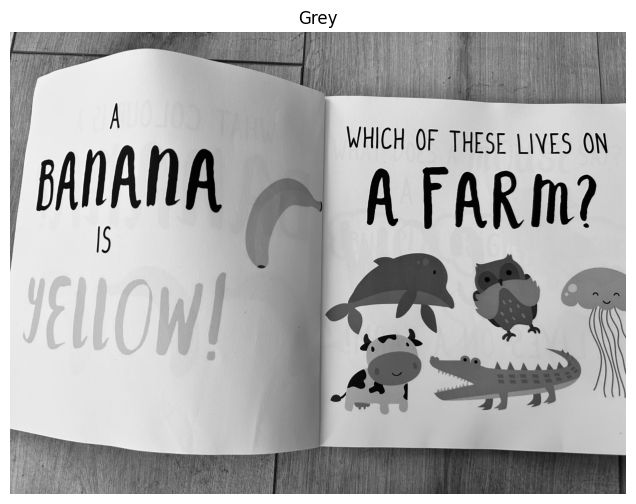

In [33]:
if 'context' in globals() and context is not None:
    print("Grayscaling pages...")
    for page in context.pages:
        img_bgr = cv2.cvtColor(np.array(page.source), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        page.add_stage(CONST_PIL_GREY, gray)
        if CONST_TRACE:
            page.plot(CONST_PIL_GREY)
else:
    print("Context is not set did you run the whole lab?")


**1.4 Denoising and Sharpening**

After grayscaling the photo, next we want to make the image easier to identify the text and images easier, so  here we remove the noise and sharpen the black and white image using automatic thresholding, as using a fixed thershold with all the possible variations of the book photos we need  system tosomething that can adapt. We use Otsu's thresholding to calculate the optimal pixel value to separate text from its background. furthermore, the technique allows the code to adapt to inconsient photo conditions, poor lighting, folded pages etc.

TODO =add source above = https://pyimagesearch.com/2014/09/01/build-kick-ass-mobile-document-scanner-just-5-minutes/ 

Denoising and sharpening pages...
looiking for index grey
added stage denoised
added stage sharp
looiking for index sharp


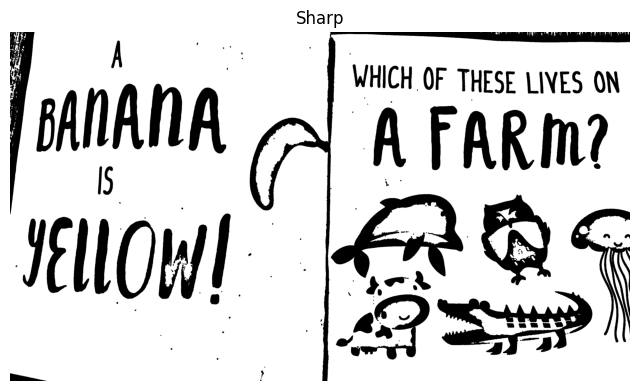

In [45]:
if 'context' in globals() and context is not None:
    print("Denoising and sharpening pages...")
    
    for page in context.pages:
        gray = page.get_stage(CONST_PIL_GREY)
        #apply a rezise given the nature of kids books and text so we have conssistanc
        #as Shourya (Medium) notes, is the single most effective way to improve accuracy
        #rescaled = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        # using open cv we can preform denosing 
        # remove the noise from the grayscale image
        denoised = cv2.fastNlMeansDenoising(gray)
        # add stage safe
        page.add_stage(CONST_PIL_DENOISE, denoised)
        # sharpen the denoised image but keep both as stages 
        sharp = cv2.adaptiveThreshold(denoised, 
            255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY, 
            255, # Increased from 31: Looks at a huge 115x115 chunk of the page to find true contrast
            11  # Increased from 15: Forces faint gray noise/speckles to become pure white
        )
        # 
        # Create a tiny pixel block and smudge to fill in the letters and remove speckles 
        #Note you can spend a long time optimizing this with iteractions and block size
        #are there not test frameworks to help find these values 
        sharp_smudged = cv2.erode(sharp, np.ones((5,5), np.uint8), iterations=1)
        
        #crope the edges as issues with piking up the background 
        #TODO even if we get this to work how generic can this be or are we going to need precise settings for differnt photos
        h, w = sharp_smudged.shape
        cropped_sharp = sharp_smudged[400:h-380, 0:w-50]
        page.add_stage(CONST_PIL_SHARP, cropped_sharp)
        if CONST_TRACE:
            page.plot(CONST_PIL_SHARP)
else:
    print("Context is not set did you run the whole lab?")

In [ ]:
if 'context' in globals() and context is not None:
    pass
else:
    print("Context is not set did you run the whole lab?")

Text Extraction (OCR)
In this step, we use Tesseract OCR to transform the preprocessed "sharp" image into a raw text string

In [53]:
if 'context' in globals() and context is not None:

    # Point pytesseract to the local Windows installation of the Tesseract engine
    tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
    pytesseract.pytesseract.tesseract_cmd = tesseract_path 
    # OEM 1 = Neural nets LSTM only
    # PSM 11 = Assume a single uniform block of text
    options = r'--oem 3 --psm 11'
    # Quick validation check to ensure the file exists at this location
    if os.path.exists(tesseract_path):
        print("OCR processing...")
        for page in context.pages:
            # get the sharpend image from context
            sharp_img = page.get_stage(CONST_PIL_SHARP)
        
            if sharp_img is not None:
                #added to see if splitting the pages improves the OCR reading 
                left_page = sharp_img[:, :w//2]
                right_page = sharp_img[:, w//2:]
                
                #Extract text from each page
                text_left = pytesseract.image_to_string(left_page, config=options)
                text_right = pytesseract.image_to_string(right_page, config=options)
                
                # Combine them or store them (storing as one string for now)
                page.raw_text = f"{text_left}\n{text_right}"
            
                if CONST_TRACE:
                    print(f"Extracted from sharpened image {page.filename} ")
                    # Print the first 100 characters to verify it worked
                    print(f"{ page.raw_text[:100]}...\n")         
    else:
        print("WARN: Tesseract executable not found, go check")
        
else:
    print("Context is not set. Did you run the previous cells?")

OCR processing...
looiking for index sharp
Extracted from sharpened image TEST_PHOTO_001.jpeg 
BANANA

)

JELLOW!

WHICH OF THESE LIVES ON

A FARM?

<n

47%

c

AP Sep
...



# Vision

## Sub Heading 1

Todo improve the cleaning bit of a hack to remove SEP invetigate a list of objects know to kids under 7 

In [55]:
if 'context' in globals() and context is not None:
    print("Analyzing extracted text for learning targets...")
    
    for page in context.pages:
        # Check if we actually extracted text in the Vision stage
        if hasattr(page, 'raw_text') and page.raw_text:
            
            # remove random lines produced by tesseart 
            clean_text = page.raw_text.replace('\n', ' ')
            # drop the whitespace
            clean_text = " ".join(clean_text.split())
            # add to nlp 
            doc = nlp(clean_text)
            
            target_objects = []
            #lets drop words under 3 chars in lenth that are not filler words 
            for token in doc:
                # PRO-MOVE: Normalize all text to lowercase
                word = token.text.lower()
                
                # if it is a Noun/Proper Noun and contains only letters 
                # keep only words over 2 chars that are non fillers
                if token.pos_ in ['NOUN', 'PROPN'] and token.is_alpha:
                    if len(word) > 3 and not token.is_stop:
                        target_objects.append(word)
            
            # save
            page.target_objects = list(set(target_objects))
            
            if CONST_TRACE:
                print(f"--- NLP Analysis for {page.filename} ---")
                print(f"Cleaned Text : {clean_text}")
                print(f"Found Objects: {page.target_objects}\n")
        else:
            print(f"WARN: No text found for {page.filename}. Skipping NLP.")
else:
    print("Context is not set. Did you run the previous cells?")

Analyzing extracted text for learning targets...
--- NLP Analysis for TEST_PHOTO_001.jpeg ---
Cleaned Text : BANANA ) JELLOW! WHICH OF THESE LIVES ON A FARM? <n 47% c AP Sep
Found Objects: ['farm', 'banana', 'jellow']



# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code